In [12]:
# ------------------------------------------------------------
# MRP dispersion across marketplaces
# ------------------------------------------------------------
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. read data ----------------------------------------------------------------
stats = pd.read_csv('outputs_integrated_full/mrp_dispersion_stats.csv')   # <-- keep the file in the same folder

# ------------------------------------------------------------
# Step 2. Reconstruct price distributions for each store
# ------------------------------------------------------------
prices = []
for _, row in stats.iterrows():
    # Extract the quantiles
    q = np.array([row['min'], row['25%'], row['50%'], row['75%'], row['max']])

    # Interpolate price samples based on number of observations
    n = int(row['count'])
    u = np.linspace(0, 1, n)
    store_prices = np.interp(u, np.linspace(0, 1, 5), q)

    # Build dataframe for this store
    prices.append(pd.DataFrame({
        'store': row['store'],
        'mrp': store_prices
    }))

# Combine all store data
df_full = pd.concat(prices, ignore_index=True)

# ------------------------------------------------------------
# Step 3. Plot the dispersion (Boxplot + Jitter)
# ------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'  # fallback if Roboto not installed

fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot: clean and pastel
# sns.boxplot(
#     data=df_full, x='store', y='mrp',
#     hue='store', palette='pastel', linewidth=1.2, ax=ax,
#     fliersize=0, width=0.6, legend=False
# )
sns.boxplot(
    data=df_full, x='store', y='mrp',
    hue='store', palette='pastel', linewidth=1.2,
    fliersize=0, width=0.6, ax=ax,
    boxprops={'zorder': 2},
    showmeans=True, meanline=True, meanprops={'color': 'red', 'ls': '--'},
    medianprops={'color': 'black', 'lw': 1.2}
)

# Add faint jitter to show underlying dispersion
sns.stripplot(
    data=df_full, x='store', y='mrp', hue='store',
    palette='dark:black', size=1.5, alpha=0.00, ax=ax
)

# Remove legend created by using hue set to the x variable (recommended by seaborn>=0.14)
try:
    if ax.legend_ is not None:
        ax.legend_.remove()
except Exception:
    pass

# ------------------------------------------------------------
# Step 4. Style the chart
# ------------------------------------------------------------
sns.despine(left=True, bottom=True)
ax.set_title('MRP Dispersion Across Marketplaces', fontsize=16, weight='bold', pad=20)
ax.set_xlabel('Store / Marketplace', fontsize=12, labelpad=10)
ax.set_ylabel('MRP (INR)', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()

# ------------------------------------------------------------
# Step 5. Save in multiple formats
# ------------------------------------------------------------
for ext, vector in [('png', False), ('pdf', True), ('svg', True)]:
    plt.savefig(
        f'mrp_dispersion_box.{ext}',
        dpi=300 if not vector else None,
        bbox_inches='tight'
    )
plt.close()

# ------------------------------------------------------------
# Figure Caption (for manuscript or report)
# ------------------------------------------------------------

# Figure 1. MRP dispersion across marketplaces.
# The boxplot illustrates the variation in Maximum Retail Price (MRP) for identical
# products across different online marketplaces. Each box represents the interquartile
# range (IQR) with the median marked inside, while the faint jittered points show
# individual price samples reconstructed from distributional statistics.
# The visualization highlights both the central tendency and spread of prices across
# stores, indicating levels of price consistency or disparity among marketplaces.


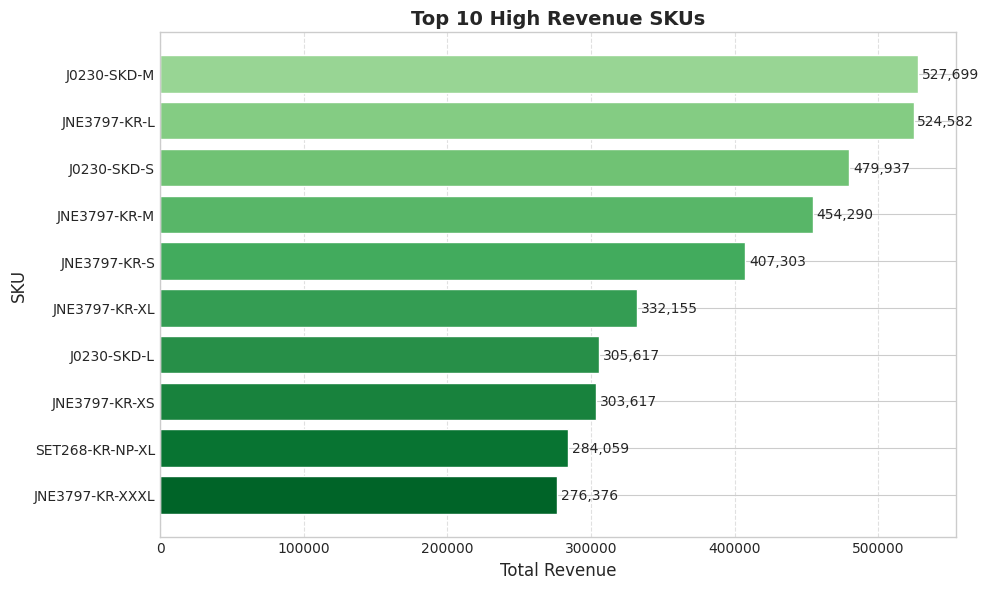

SVG chart saved as: top_10_skus_green_gradient.pdf


In [15]:
# ==========================================
# Plot Top 10 High Revenue SKUs with Gradient
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Read the CSV file
file_path = "outputs_integrated_full/top_skus.csv"   # Change path if needed
top_skus_df = pd.read_csv(file_path)

# Step 2: Sort by total revenue and select top 10
top_10_skus = top_skus_df.sort_values(by="total_revenue", ascending=False).head(10)

# Step 3: Create a green color gradient
num_bars = len(top_10_skus)
colors = plt.cm.Greens(np.linspace(0.4, 0.9, num_bars))

# Step 4: Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_skus["SKU"], top_10_skus["total_revenue"], color=colors)

# Step 5: Beautify the chart
plt.xlabel("Total Revenue", fontsize=12)
plt.ylabel("SKU", fontsize=12)
plt.title("Top 10 High Revenue SKUs", fontsize=14, weight="bold")
plt.gca().invert_yaxis()  # Highest revenue at top
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Add value labels to bars
for bar in bars:
    plt.text(
        bar.get_width() + max(top_10_skus["total_revenue"]) * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():,.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

# Step 6: Save the figure as SVG
output_path = "top_10_skus_green_gradient.pdf"
plt.savefig(output_path, format="pdf")
plt.show()

print(f"SVG chart saved as: {output_path}")


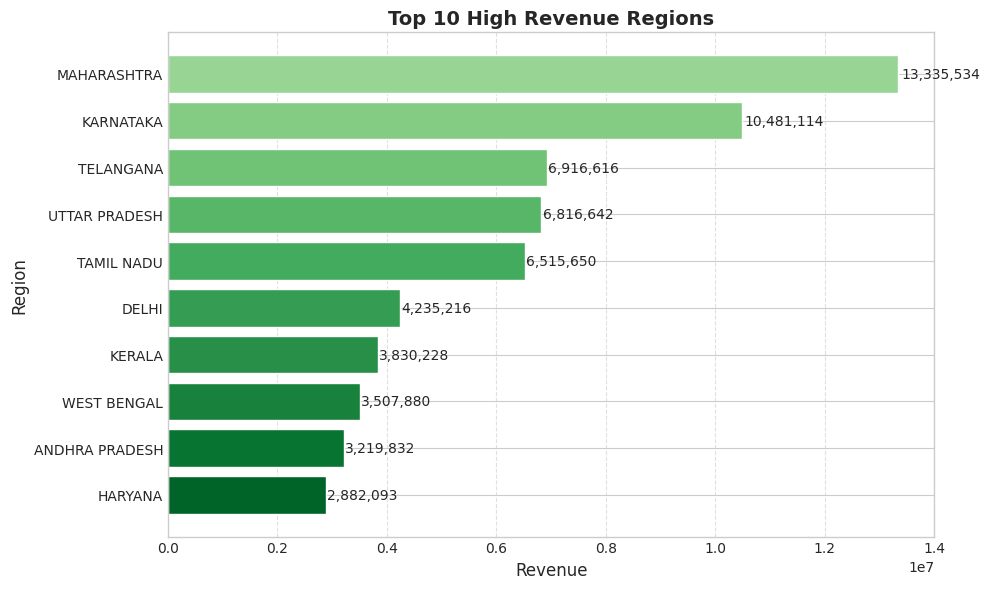

Chart saved as: top_10_regions_green_gradient.pdf


In [17]:
# ==========================================
# Plot Top 10 High Revenue Sales with Gradient (by Region)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Read the CSV file
file_path = "outputs_integrated_full/sales_by_region.csv"   # Keep path relative to project root
region_df = pd.read_csv(file_path)

# The CSV has columns: region, revenue. Fix column usage accordingly.

# Step 2: Sort by revenue and select top 10 regions
top_10_regions = region_df.sort_values(by="revenue", ascending=False).head(10)

# Step 3: Create a green color gradient
num_bars = len(top_10_regions)
colors = plt.cm.Greens(np.linspace(0.4, 0.9, num_bars))

# Step 4: Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10_regions["region"], top_10_regions["revenue"], color=colors)

# Step 5: Beautify the chart
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Region", fontsize=12)
plt.title("Top 10 High Revenue Regions", fontsize=14, weight="bold")
plt.gca().invert_yaxis()  # Highest revenue at top
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Add value labels to bars
for bar in bars:
    plt.text(
        bar.get_width() * 1.005,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():,.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

# Step 6: Save the figure as PDF
output_path = "top_10_regions_green_gradient.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Chart saved as: {output_path}")
